In [1]:
import sys
from pathlib import Path
_r = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts' / 'config.py').exists())
sys.path.insert(0, str(_r / 'scripts'))

from notebook_init import setup
cfg, PATHS, POPULATIONS, HARD_FILTERS, SITUATIONAL_FILTERS, ML = setup()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import subprocess
from scipy.stats import chi2_contingency, entropy
from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.multitest import fdrcorrection
from utils import count_variants
print("All imports successful!")
import os


Project root : /home/ibmelab/Projects/AISNP_Research
genomes_data : /mnt/data/aisnp_data/1000genomes/
output root  : output
All imports successful!


In [2]:
INPUT_PFILE = str(PATHS.PLINK_LD_PRUNED)

import os, time
import numpy as np
from tqdm import tqdm
from plink import run_plink2_command

NUMPY_CACHE = str(PATHS.GENOTYPE_MATRIX)
COLS_CACHE  = str(PATHS.GENOTYPE_MATRIX_COLS)
TEMP_VCF    = str(PATHS.cache_dir('04a_statistical_snp_selection') / 'temp_vcf')

GT_MAP = {
    '0/0': 0, '0|0': 0,
    '0/1': 1, '1/0': 1, '0|1': 1, '1|0': 1,
    '1/1': 2, '1|1': 2,
}

def _build_from_vcf(vcf_path):
    genotypes, sample_names = {}, []
    with open(vcf_path) as fh:
        for line in tqdm(fh, desc='Parsing VCF'):
            if line.startswith('##'): continue
            if line.startswith('#CHROM'):
                sample_names = line.strip().split('\t')[9:]
                continue
            fields = line.strip().split('\t')
            snp_id = fields[2] if fields[2] != '.' else f'{fields[0]}:{fields[1]}'
            genotypes[snp_id] = [GT_MAP.get(g.split(':')[0], -1) for g in fields[9:]]
    return pd.DataFrame(genotypes, index=sample_names).astype(np.int8)

if os.path.exists(NUMPY_CACHE) and os.path.exists(COLS_CACHE):
    print('Loading numpy cache...')
    t0 = time.time()
    data = np.load(NUMPY_CACHE)
    raw_df = pd.DataFrame(
        data['G'],
        index=list(data['samples'].astype(str)),
        columns=open(COLS_CACHE).read().splitlines(),
    )
    print(f'Loaded in {time.time()-t0:.1f}s: {raw_df.shape}')
else:
    print('Cache not found — building from pfile...')
    os.makedirs(str(PATHS.cache_dir('04a_statistical_snp_selection')), exist_ok=True)
    os.makedirs(str(PATHS.outputs_dir('03_vcf_to_matrix')), exist_ok=True)
    run_plink2_command(['--pfile', str(PATHS.PLINK_LD_PRUNED), '--export', 'vcf', '--out', TEMP_VCF])
    raw_df = _build_from_vcf(f'{TEMP_VCF}.vcf')
    print(f'Matrix built: {raw_df.shape}')
    np.savez_compressed(NUMPY_CACHE, G=raw_df.values, samples=np.array(raw_df.index, dtype=str))
    with open(COLS_CACHE, 'w') as fh:
        fh.write('\n'.join(raw_df.columns))
    print(f'Saved: {NUMPY_CACHE}')
    for ext in ['.vcf', '.log']:
        p = TEMP_VCF + ext
        if os.path.exists(p): os.remove(p)

# Add population labels
samples_meta = pd.read_csv(str(PATHS.SAMPLES_CSV), header=None, names=['sample', 'pop', 'super_pop'])
genotype_df = raw_df.reset_index().rename(columns={'index': 'sample'})
genotype_df = genotype_df.merge(samples_meta[['sample', 'pop']], on='sample', how='left')
genotype_df = genotype_df[['sample', 'pop'] + [c for c in genotype_df.columns if c not in ['sample', 'pop']]]

snp_columns = [c for c in genotype_df.columns if c not in ['sample', 'pop']]
populations = genotype_df['pop']
print(f'Ready: {genotype_df.shape}')
print(f'Populations: {populations.value_counts().to_dict()}')


Loading numpy cache...


Loaded in 0.7s: (504, 614759)
Ready: (504, 614761)
Populations: {'CN': 208, 'SEA': 192, 'JPT': 104}


## Step 3: Define Statistical Tests

In [3]:
# Extract features and labels
snp_columns = [c for c in genotype_df.columns if c not in ['sample', 'pop']]
populations = genotype_df['pop']
genotypes = genotype_df[snp_columns]

print(f"SNPs to analyze: {len(snp_columns)}")
print(f"Populations: {populations.unique()}")

SNPs to analyze: 614759
Populations: ['CN' 'SEA' 'JPT']


In [4]:
from stats import compute_snp_stats_vectorized


In [5]:
# Quick sanity check on 5 SNPs using the vectorised function
sample_df = genotype_df[['sample', 'pop'] + snp_columns[:5]]
sample_res = compute_snp_stats_vectorized(sample_df, populations, verbose=False)
print('Sanity check (5 SNPs):')
print(sample_res[['snp_id','chi2','mutual_information','kl_divergence']].to_string(index=False))


Sanity check (5 SNPs):
         snp_id      chi2  mutual_information  kl_divergence
1:13116[b37]T,G 30.227053            0.023392       0.090887
1:13273[b37]G,C 28.997183            0.026863       0.149397
1:13289[b37]C,T  1.315523            0.001805       0.046975
1:13543[b37]T,G  1.315523            0.001805       0.046975
1:14599[b37]T,A 31.331957            0.027324       0.152791


## Step 4: Run Analysis on All SNPs

In [6]:
import os

cached_results_path = str(PATHS.STAT_SCORES)

if os.path.exists(cached_results_path):
    print(f'Loading cached results: {cached_results_path}')
    results_df = pd.read_csv(cached_results_path)
    print(f'Loaded {len(results_df):,} SNP results.')
else:
    print(f'Computing stats for {len(snp_columns):,} SNPs (vectorised)...')
    results_df = compute_snp_stats_vectorized(genotype_df, populations)
    os.makedirs(str(PATHS.outputs_dir('04a_statistical_snp_selection')), exist_ok=True)
    results_df.to_csv(cached_results_path, index=False)
    print(f'Saved: {cached_results_path}')

print(f'Results shape: {results_df.shape}')


Loading cached results: /mnt/data/aisnp_data/1000genomes/outputs/04a_statistical_snp_selection/statistical_snp_scores.csv
Loaded 614,759 SNP results.
Results shape: (614759, 13)


In [7]:
# Summary statistics
print("Summary Statistics:")
print("="*60)
display(results_df.describe())

print("\nMissing Values:")
print(results_df.isna().sum())

Summary Statistics:


,chi2,chi2_pvalue,mutual_information,kl_divergence,chi2_qvalue,rank_chi2,rank_mi,rank_kl,composite_rank,tests_passed
count,614759.000000,6.147590e+05,614759.000000,614759.000000,6.147590e+05,614759.000000,614759.00000,614759.000000,614759.000000,614759.00000
mean,5.377454,4.843866e-01,0.005705,0.070843,7.681196e-01,307380.000000,307380.00000,307380.000000,307380.000000,0.05476
std,6.317007,3.392737e-01,0.005950,0.090968,3.225110e-01,177462.016583,177462.55434,177461.493517,164470.272352,0.23570
min,0.000000,8.483677e-37,0.000000,0.000000,5.215417e-31,1.000000,1.00000,1.000000,1.666667,0.00000
25%,1.591057,1.559969e-01,0.001849,0.010414,6.201424e-01,153690.500000,153690.50000,153668.000000,173828.166667,0.00000
50%,3.394270,4.941359e-01,0.004007,0.045355,9.738028e-01,307160.000000,308476.00000,311868.000000,300334.500000,0.00000
75%,6.643056,8.103987e-01,0.007341,0.094386,1.000000e+00,463153.500000,460563.00000,461004.500000,435536.666667,0.00000
max,175.081940,1.000000e+00,0.192157,2.856276,1.000000e+00,614759.000000,614759.00000,614759.000000,614759.000000,3.00000



Missing Values:
snp_id                   0
chi2                     0
chi2_pvalue              0
mutual_information       0
kl_divergence            0
chi2_qvalue              0
chi2_significant_fdr     0
chi2_significant_bonf    0
rank_chi2                0
rank_mi                  0
rank_kl                  0
composite_rank           0
tests_passed             0
dtype: int64


## Step 5: Multiple Testing Correction & Significance

In [8]:
# Apply FDR correction
alpha = 0.05
n_tests = len(results_df)
bonferroni_alpha = alpha / n_tests

print(f"Multiple Testing Correction:")
print(f"  Original α: {alpha}")
print(f"  Number of tests: {n_tests}")
print(f"  Bonferroni α: {bonferroni_alpha:.2e}")

# FDR correction for chi2
chi2_pvals = results_df['chi2_pvalue'].fillna(1).values
chi2_reject, chi2_qvals = fdrcorrection(chi2_pvals, alpha=alpha)
results_df['chi2_qvalue'] = chi2_qvals
results_df['chi2_significant_fdr'] = chi2_reject
results_df['chi2_significant_bonf'] = results_df['chi2_pvalue'] < bonferroni_alpha

print(f"\nSignificant SNPs (χ² test):")
print(f"  FDR (q < {alpha}): {results_df['chi2_significant_fdr'].sum()}")
print(f"  Bonferroni (p < {bonferroni_alpha:.2e}): {results_df['chi2_significant_bonf'].sum()}")

Multiple Testing Correction:
  Original α: 0.05
  Number of tests: 614759
  Bonferroni α: 8.13e-08



Significant SNPs (χ² test):
  FDR (q < 0.05): 32664
  Bonferroni (p < 8.13e-08): 2865


In [9]:
# Identify consensus SNPs (significant across multiple tests)
from collections import Counter

# Use FDR for chi2, top 500 for other metrics
sig_chi2 = set(results_df[results_df['chi2_significant_fdr']]['snp_id'])
sig_mi = set(results_df.nlargest(500, 'mutual_information')['snp_id'])
sig_kl = set(results_df.nlargest(500, 'kl_divergence')['snp_id'])

print("SNPs Selected by Each Test:")
print("="*60)
print(f"χ² (FDR significant): {len(sig_chi2)}")
print(f"MI (top 500): {len(sig_mi)}")
print(f"KL (top 500): {len(sig_kl)}")

# Count overlap
all_sig = list(sig_chi2) + list(sig_mi) + list(sig_kl)
snp_counts = Counter(all_sig)

snps_in_3 = [s for s, c in snp_counts.items() if c == 3]
snps_in_2 = [s for s, c in snp_counts.items() if c >= 2]

print(f"\nConsensus SNPs:")
print(f"  All 3 tests: {len(snps_in_3)}")
print(f"  ≥2 tests: {len(snps_in_2)}")

SNPs Selected by Each Test:
χ² (FDR significant): 32664
MI (top 500): 500
KL (top 500): 500

Consensus SNPs:
  All 3 tests: 171
  ≥2 tests: 824


## Step 6: Visualizations

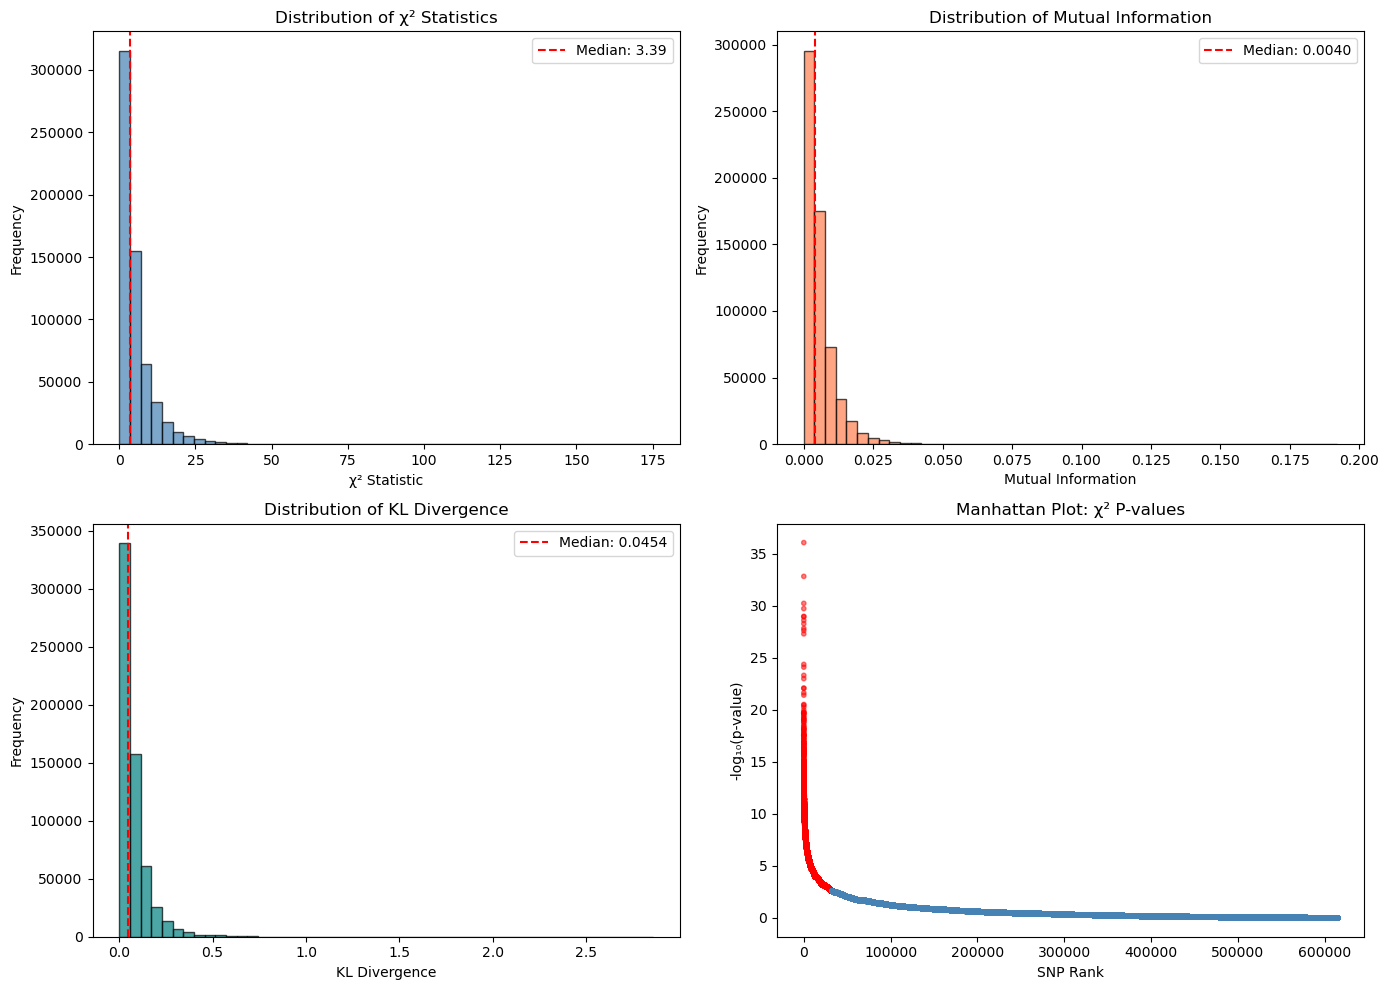

In [10]:
# Visualization panel
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: χ² distribution
ax = axes[0, 0]
ax.hist(results_df['chi2'].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(results_df['chi2'].median(), color='red', linestyle='--', 
           label=f'Median: {results_df["chi2"].median():.2f}')
ax.set_xlabel('χ² Statistic')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of χ² Statistics')
ax.legend()

# Plot 2: MI distribution
ax = axes[0, 1]
ax.hist(results_df['mutual_information'].dropna(), bins=50, color='coral', edgecolor='black', alpha=0.7)
ax.axvline(results_df['mutual_information'].median(), color='red', linestyle='--',
           label=f'Median: {results_df["mutual_information"].median():.4f}')
ax.set_xlabel('Mutual Information')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Mutual Information')
ax.legend()

# Plot 3: KL divergence distribution
ax = axes[1, 0]
ax.hist(results_df['kl_divergence'].dropna(), bins=50, color='teal', edgecolor='black', alpha=0.7)
ax.axvline(results_df['kl_divergence'].median(), color='red', linestyle='--',
           label=f'Median: {results_df["kl_divergence"].median():.4f}')
ax.set_xlabel('KL Divergence')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of KL Divergence')
ax.legend()

# Plot 4: -log10(p-value) Manhattan-style
ax = axes[1, 1]
log_p = -np.log10(results_df['chi2_pvalue'].clip(lower=1e-300))
sorted_df = results_df.sort_values('chi2', ascending=False).reset_index(drop=True)
colors = ['red' if sig else 'steelblue' for sig in sorted_df['chi2_significant_fdr']]
ax.scatter(range(len(sorted_df)), -np.log10(sorted_df['chi2_pvalue'].clip(lower=1e-300)),
           c=colors, alpha=0.5, s=10)
ax.set_xlabel('SNP Rank')
ax.set_ylabel('-log₁₀(p-value)')
ax.set_title('Manhattan Plot: χ² P-values')

plt.tight_layout()
plt.show()

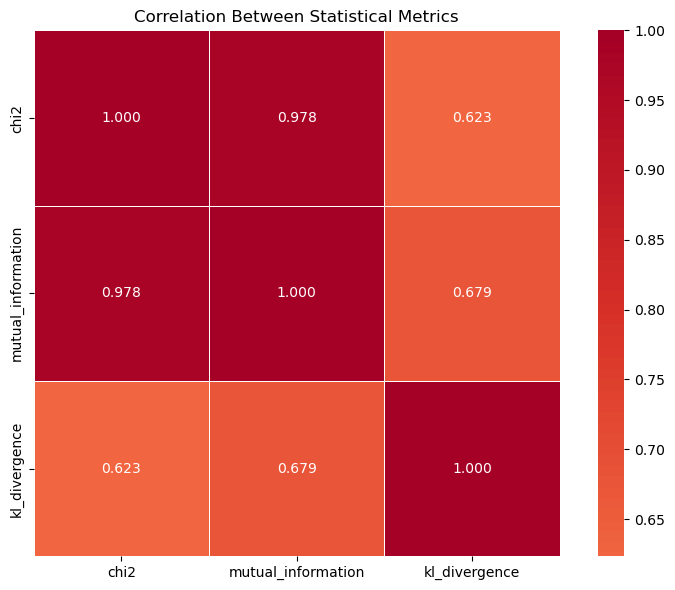

In [11]:
# Correlation heatmap
metric_cols = ['chi2', 'mutual_information', 'kl_divergence']
corr_matrix = results_df[metric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0,
            fmt='.3f', square=True, linewidths=0.5)
plt.title('Correlation Between Statistical Metrics')
plt.tight_layout()
plt.show()

## Step 7: Select Top SNPs and Create Ranking

In [12]:
# Create composite ranking
results_df['rank_chi2'] = results_df['chi2'].rank(ascending=False)
results_df['rank_mi'] = results_df['mutual_information'].rank(ascending=False)
results_df['rank_kl'] = results_df['kl_divergence'].rank(ascending=False)

# Average rank (lower is better)
results_df['composite_rank'] = (results_df['rank_chi2'] + results_df['rank_mi'] + 
                                 results_df['rank_kl']) / 3

# Add consensus count column
results_df['tests_passed'] = results_df['snp_id'].apply(lambda x: snp_counts.get(x, 0))

# Filter for SNPs that passed ALL 3 tests
results_df_all3 = results_df[results_df['tests_passed'] == 3].copy()
results_df_all3_sorted = results_df_all3.sort_values('composite_rank')

# Also keep full sorted results for reference
results_df_sorted = results_df.sort_values('composite_rank')

print(f"SNPs passing ALL 3 tests: {len(results_df_all3_sorted)}")
print(f"\nTop 25 SNPs (All 3 Tests Passed):")
print("="*80)
display(results_df_all3_sorted[['snp_id', 'chi2', 'mutual_information',
                                 'kl_divergence', 'composite_rank', 'tests_passed']].head(25))

SNPs passing ALL 3 tests: 171

Top 25 SNPs (All 3 Tests Passed):


,snp_id,chi2,mutual_information,kl_divergence,composite_rank,tests_passed
0,"4:17813761[b37]G,A",175.081940,0.192157,2.268300,1.666667,3
1,"1:12387655[b37]G,A",159.962070,0.173566,2.211642,2.666667,3
2,"14:96938945[b37]A,T",138.716920,0.160640,2.856276,4.333333,3
3,"5:41181491[b37]G,T",142.028440,0.155135,1.900760,6.000000,3
4,"11:112053732[b37]T,A",102.374985,0.118875,2.152359,13.333333,3
5,"1:102457870[b37]G,A",114.027145,0.094362,1.962984,13.666667,3
6,"20:33681323[b37]T,C",109.724236,0.090733,1.901932,16.000000,3
7,"6:170619277[b37]G,A",109.724236,0.090733,1.888224,16.666667,3
8,"6:82912256[b37]T,A",107.634870,0.121366,1.422121,23.666667,3
9,"1:241502631[b37]T,C",101.172320,0.083539,1.739370,29.000000,3


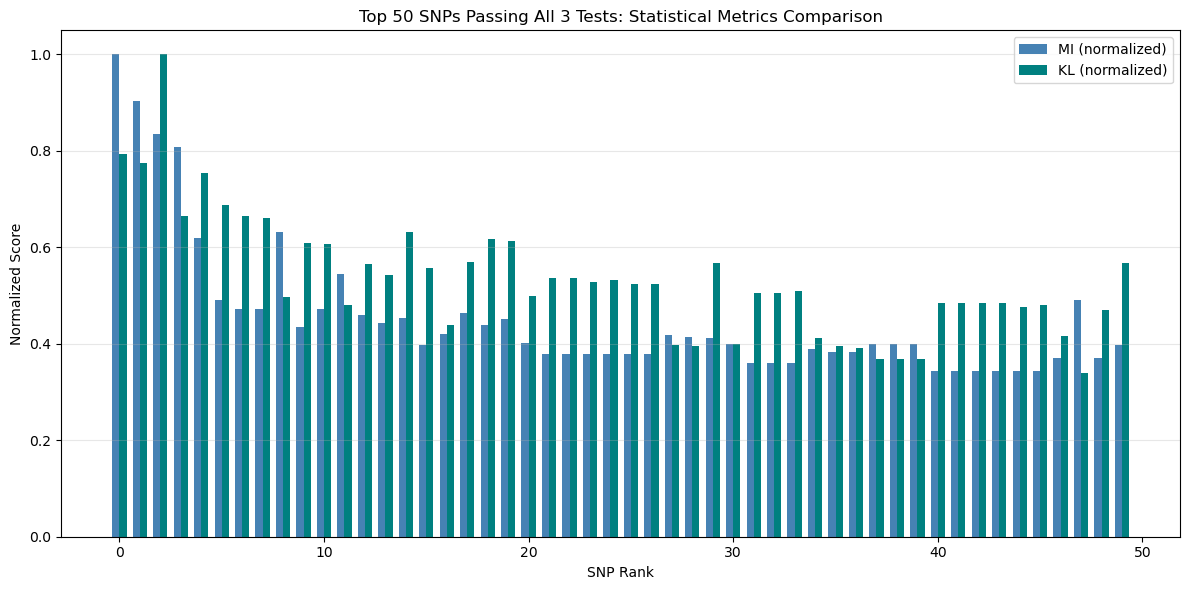


Total SNPs passing all 3 tests: 171


In [13]:
# Top SNPs visualization (using SNPs that passed all 3 tests)
fig, ax = plt.subplots(figsize=(12, 6))

top_snps = results_df_all3_sorted
n_display = min(50, len(top_snps))
x = np.arange(n_display)

if len(top_snps) > 0:
    # Normalize metrics for comparison
    mi_norm = top_snps['mutual_information'].head(n_display) / top_snps['mutual_information'].max()
    kl_norm = top_snps['kl_divergence'].head(n_display) / top_snps['kl_divergence'].max()

    width = 0.35
    ax.bar(x - width/2, mi_norm, width, label='MI (normalized)', color='steelblue')
    ax.bar(x + width/2, kl_norm, width, label='KL (normalized)', color='teal')

    ax.set_xlabel('SNP Rank')
    ax.set_ylabel('Normalized Score')
    ax.set_title(f'Top {n_display} SNPs Passing All 3 Tests: Statistical Metrics Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
else:
    ax.text(0.5, 0.5, 'No SNPs passed all 3 tests', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('No SNPs Passed All 3 Tests')

plt.tight_layout()
plt.show()

print(f"\nTotal SNPs passing all 3 tests: {len(results_df_all3_sorted)}")

## Step 8: Save Results

In [14]:
# Save full results
output_path = str(PATHS.STAT_SCORES)
results_df_sorted.to_csv(output_path, index=False)
print(f"Full results saved: {output_path}")

# Save SNPs that passed ALL 3 tests (primary output)
all3_snps_path = str(PATHS.outputs_dir("04a_statistical_snp_selection") / "statistical_all3_snps.csv")
results_df_all3_sorted.to_csv(all3_snps_path, index=False)
print(f"SNPs passing all 3 tests saved: {all3_snps_path} ({len(results_df_all3_sorted)} SNPs)")

# Save SNP IDs only (for PLINK extraction) - using all 3 tests filter
all3_ids_path = str(PATHS.outputs_dir("04a_statistical_snp_selection") / "statistical_all3_snp_ids.txt")
results_df_all3_sorted[['snp_id']].to_csv(all3_ids_path, index=False, header=False)
print(f"All-3-tests SNP IDs saved: {all3_ids_path}")

# Save alias for downstream notebooks expecting "all4" name
all4_snps_path = str(PATHS.STAT_ALL4_SNPS)
results_df_all3_sorted.to_csv(all4_snps_path, index=False)
print(f"Alias saved: {all4_snps_path}")

# Also save top N for backward compatibility
top_n = SITUATIONAL_FILTERS.FST_TOP_N
top_snps_df = results_df_sorted.head(top_n)
top_snps_path = str(PATHS.outputs_dir("04a_statistical_snp_selection") / "statistical_top_snps.csv")
top_snps_df.to_csv(top_snps_path, index=False)
print(f"Top {top_n} SNPs (by rank) saved: {top_snps_path}")

top_ids_path = str(PATHS.outputs_dir("04a_statistical_snp_selection") / "statistical_top_snp_ids.txt")
top_snps_df[['snp_id']].to_csv(top_ids_path, index=False, header=False)
print(f"Top {top_n} SNP IDs saved: {top_ids_path}")

# Save ML data with ONLY all-3-tests SNPs (memory efficient for downstream ML)
all3_snp_ids = results_df_all3_sorted['snp_id'].tolist()
available_all3_snps = [s for s in all3_snp_ids if s in genotype_df.columns]
ml_cols = ['sample', 'pop'] + available_all3_snps
ml_data_all3 = genotype_df[ml_cols]

ml_data_path = str(PATHS.STAT_ML_DATA)
ml_data_all3.to_csv(ml_data_path, index=False)
print(f"ML data (all-3-tests SNPs only) saved: {ml_data_path}")
print(f"  → {len(available_all3_snps)} SNPs, {len(ml_data_all3)} samples")

Full results saved: /mnt/data/aisnp_data/1000genomes/outputs/04a_statistical_snp_selection/statistical_snp_scores.csv
SNPs passing all 3 tests saved: /mnt/data/aisnp_data/1000genomes/outputs/04a_statistical_snp_selection/statistical_all3_snps.csv (171 SNPs)
All-3-tests SNP IDs saved: /mnt/data/aisnp_data/1000genomes/outputs/04a_statistical_snp_selection/statistical_all3_snp_ids.txt
Alias saved: /mnt/data/aisnp_data/1000genomes/outputs/04a_statistical_snp_selection/statistical_all4_snps.csv
Top 1000 SNPs (by rank) saved: /mnt/data/aisnp_data/1000genomes/outputs/04a_statistical_snp_selection/statistical_top_snps.csv
Top 1000 SNP IDs saved: /mnt/data/aisnp_data/1000genomes/outputs/04a_statistical_snp_selection/statistical_top_snp_ids.txt
ML data (all-3-tests SNPs only) saved: /mnt/data/aisnp_data/1000genomes/outputs/04a_statistical_snp_selection/statistical_ml_data.csv
  → 171 SNPs, 504 samples


## Summary

In [15]:
print("="*70)
print("STATISTICAL SNP SELECTION SUMMARY")
print("="*70)

print(f"\nInput:")
print(f"  Pfile: {INPUT_PFILE}")
print(f"  Samples: {len(genotype_df)}")
print(f"  SNPs analyzed: {len(snp_columns)}")
print(f"  Populations: {list(populations.unique())}")

print(f"\nStatistical Tests:")
print(f"  1. Pearson χ² test (FDR corrected)")
print(f"  2. Mutual Information (top 500)")
print(f"  3. KL Divergence (top 500)")

print(f"\nFiltering Results:")
print(f"  χ² FDR significant: {results_df['chi2_significant_fdr'].sum()}")
print(f"  Consensus (≥2 tests): {len(snps_in_2)}")
print(f"  ★ Passed ALL 3 tests: {len(snps_in_3)}")

if len(results_df_all3_sorted) > 0:
    print(f"\nTop SNP (All 3 Tests):")
    top = results_df_all3_sorted.iloc[0]
    print(f"  {top['snp_id']}")
    print(f"  χ²: {top['chi2']:.2f}, MI: {top['mutual_information']:.4f}, KL: {top['kl_divergence']:.4f}")

print(f"\nOutput Files:")
print(f"  - statistical_snp_scores_02b.csv (all results)")
print(f"  - statistical_all3_snps_02b.csv ({len(results_df_all3_sorted)} SNPs passing all 3 tests) ★")
print(f"  - statistical_all3_snp_ids_02b.txt (IDs for PLINK extraction) ★")
print(f"  - statistical_top_snps_02b.csv (top {top_n} by composite rank)")
print(f"  - statistical_ml_data_02b.csv (genotype matrix)")

print(f"\nNext Steps:")
print(f"  Option A: Run 03_fst_and_pca.ipynb (FST-based selection)")
print(f"  Option B: Run 04_ml_training.ipynb with all-4-tests SNPs")
print(f"  Option C: Compare both methods in 04b_ml_training_statistical.ipynb")

STATISTICAL SNP SELECTION SUMMARY

Input:
  Pfile: /mnt/data/aisnp_data/1000genomes/outputs/02_situational_filtering/SEA_JPT_CN_LD_pruned
  Samples: 504
  SNPs analyzed: 614759
  Populations: ['CN', 'SEA', 'JPT']

Statistical Tests:
  1. Pearson χ² test (FDR corrected)
  2. Mutual Information (top 500)
  3. KL Divergence (top 500)

Filtering Results:
  χ² FDR significant: 32664
  Consensus (≥2 tests): 824
  ★ Passed ALL 3 tests: 171

Top SNP (All 3 Tests):
  4:17813761[b37]G,A
  χ²: 175.08, MI: 0.1922, KL: 2.2683

Output Files:
  - statistical_snp_scores_02b.csv (all results)
  - statistical_all3_snps_02b.csv (171 SNPs passing all 3 tests) ★
  - statistical_all3_snp_ids_02b.txt (IDs for PLINK extraction) ★
  - statistical_top_snps_02b.csv (top 1000 by composite rank)
  - statistical_ml_data_02b.csv (genotype matrix)

Next Steps:
  Option A: Run 03_fst_and_pca.ipynb (FST-based selection)
  Option B: Run 04_ml_training.ipynb with all-4-tests SNPs
  Option C: Compare both methods in 04b_m